In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import json
import seaborn as sns

In [35]:
def inertia(X, labels, centers):
    total = 0
    for c in range(len(centers)):
        points = X[labels == c]
        total += np.sum((points - centers[c]) ** 2)
    return total

def pairwise_distances(X, centers):
    return np.sqrt(((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2))

def kmeans_plus_plus_init(X, k, random_state=42):
    np.random.seed(random_state)
    n = X.shape[0]

    centers = np.zeros((k, X.shape[1]))
    # pick first center randomly
    idx = np.random.randint(0, n)
    centers[0] = X[idx]

    # distance to first center
    dist_sq = np.sum((X - centers[0])**2, axis=1)

    # pick remaining centers
    for i in range(1, k):
        probs = dist_sq / np.sum(dist_sq)
        cumprobs = np.cumsum(probs)
        r = np.random.rand()
        idx = np.searchsorted(cumprobs, r)
        centers[i] = X[idx]

        new_dist_sq = np.sum((X - centers[i])**2, axis=1)
        dist_sq = np.minimum(dist_sq, new_dist_sq)

    return centers

def kmeans_fit(X, k, max_iter=300, tol=1e-4, random_state=42):
    centers = kmeans_plus_plus_init(X, k, random_state=random_state)

    for it in range(max_iter):
        dists = pairwise_distances(X, centers)
        labels = np.argmin(dists, axis=1)

        new_centers = np.zeros_like(centers)
        for c in range(k):
            if np.any(labels == c):
                new_centers[c] = X[labels == c].mean(axis=0)
            else:
                new_centers[c] = centers[c]

        shift = np.sum((new_centers - centers)**2)
        centers = new_centers

        if shift < tol:
            break

    final_dists = pairwise_distances(X, centers)
    labels = np.argmin(final_dists, axis=1)
    sse = inertia(X, labels, centers)

    return {"labels": labels, "centers": centers, "inertia": sse, "iterations": it+1}

# ------------------------------------------------------------
# MAIN PIPELINE
# ------------------------------------------------------------
def run_clustering(path, out_prefix="kmeans_output"):
    # Load data (Excel or CSV)
    if path.endswith(".xlsx"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)

    # ------------------------------
    # FEATURES TO USE
    # ------------------------------
    numeric = [
        "Age", "Income", "Recency",
        "NumWebVisitsMonth", "Kidhome", "Teenhome", "MntWines",
        "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
        "MntGoldProds", "NumDealsPurchases", "NumCatalogPurchases",
        "NumStorePurchases", "NumWebPurchases", "AcceptedCmp3","AcceptedCmp4",
        "AcceptedCmp5", "AcceptedCmp1", "AcceptedCmp2", "Complain",
        "Response"
    ]

    outcome_cols = [
        "AcceptedCmp3","AcceptedCmp4","AcceptedCmp5",
        "AcceptedCmp1","AcceptedCmp2","Complain","Response"
    ]

    categorical = ["Education", "Marital_Status"]

    # ------------------------------
    # ONE-HOT ENCODING
    # ------------------------------
    df_encoded = pd.get_dummies(df[numeric + categorical], drop_first=False)

    # Drop NA
    df_encoded = df_encoded.dropna()

    # Convert to numpy
    X = df_encoded.values.astype(float)

    # ------------------------------
    # SCALING
    # ------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    ks = [2, 5, 7, 9]

    SSE = []
    SIL = []
    results = {}

    for k in ks:
        print(f"\nRunning KMeans from scratch for k={k}...")
        res = kmeans_fit(X_scaled, k)
        labels = res["labels"]

        results[k] = res
        SSE.append(res["inertia"])
        sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else None
        SIL.append(sil)

        df[f"cluster_k{k}"] = labels
        print(f"  SSE = {res['inertia']:.2f}, Silhouette = {sil}")

    # Save CSV
    df.to_csv(f"{out_prefix}_with_clusters.csv", index=False)

    # ------------------------------
    # GENERATE CLUSTER SUMMARY
    #------------------------------
    summary = {}
    for k in ks:
        labels = df[f"cluster_k{k}"]
        cluster_profiles = []

        for c in range(k):
            members = df[labels == c]
            profile = {
                "cluster": c,
                "count": len(members),
                "percentage": float(len(members)) / len(df) * 100,
                "numeric_means": members[numeric].mean().to_dict(),
                "education_distribution": members["Education"].value_counts(normalize=True).to_dict(),
                "marital_distribution": members["Marital_Status"].value_counts(normalize=True).to_dict(),
                "campaign_response_rates": members[outcome_cols].mean().to_dict()
            }
            cluster_profiles.append(profile)

        summary[k] = {
            "SSE": results[k]["inertia"],
            "Silhouette": SIL[ks.index(k)],
            "Clusters": cluster_profiles
        }

    # Save summary JSON
    with open(f"{out_prefix}_summary.json", "w") as f:
        json.dump(summary, f, indent=4)

    # Elbow plot
    plt.figure(figsize=(6,4))
    plt.plot(ks, SSE, marker="o")
    plt.title("Elbow Method (SSE)")
    plt.xlabel("k")
    plt.ylabel("SSE")
    plt.grid(True)
    plt.savefig(f"{out_prefix}_elbow.png")
    plt.show()
    plt.close()

    # Silhouette plot
    plt.figure(figsize=(6,4))
    plt.plot(ks, SIL, marker="o")
    plt.title("Silhouette Scores")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.savefig(f"{out_prefix}_silhouette.png")
    plt.show()
    plt.close()

    print("\nAll done! Outputs saved.\n")


Running KMeans from scratch for k=2...
  SSE = 27816.05, Silhouette = 0.1744782604818972

Running KMeans from scratch for k=5...
  SSE = 24278.16, Silhouette = 0.10751116440197177

Running KMeans from scratch for k=7...
  SSE = 22779.69, Silhouette = 0.11351648039378924

Running KMeans from scratch for k=9...
  SSE = 21299.13, Silhouette = 0.09853399288371904


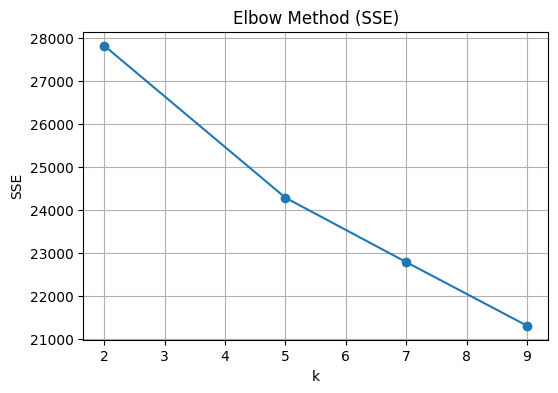

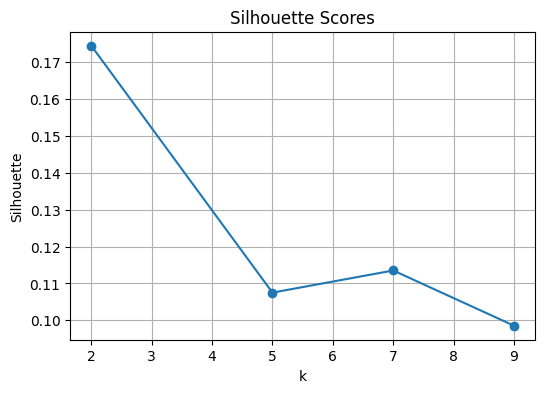


All done! Outputs saved.



In [36]:
run_clustering(
    r"C:\Users\keert\OneDrive\Desktop\M25 Data Analytics I Assignment-4\pre-processed_data_1.xlsx",
    out_prefix="kmeans_output"
)

In [37]:
SUMMARY_PATH = r"C:\Users\keert\OneDrive\Desktop\M25 Data Analytics I Assignment-4\kmeans_output_summary.json"
DATA_PATH = r"C:\Users\keert\OneDrive\Desktop\M25 Data Analytics I Assignment-4\kmeans_output_with_clusters.csv"

with open(SUMMARY_PATH, "r") as f:
    summary = json.load(f)

# READ CSV
df = pd.read_csv(DATA_PATH)

# We restrict analysis to k = 2
k = 2
k_str = str(k)

clusters_summary = summary[k_str]["Clusters"]

def print_heading(text):
    print("\n" + "=" * 80)
    print(text)
    print("=" * 80)

def plot_cluster_sizes():
    cluster_counts = df[f"cluster_k{k}"].value_counts().sort_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
    plt.title(f"Cluster Sizes (k = {k})")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"cluster_{k}_sizes.png")
    plt.show()
    plt.close()

def plot_education():
    edu_df = pd.DataFrame(
        {f"Cluster {c['cluster']}": c["education_distribution"] for c in clusters_summary}
    ).fillna(0)

    edu_df.T.plot(kind="bar", stacked=True, figsize=(8,5))
    plt.title(f"Education Distribution by Cluster (k={k})")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.savefig(f"cluster_{k}_education.png")
    plt.show()
    plt.close()

def plot_marital():
    mar_df = pd.DataFrame(
        {f"Cluster {c['cluster']}": c["marital_distribution"] for c in clusters_summary}
    ).fillna(0)

    mar_df.T.plot(kind="bar", stacked=True, figsize=(8,5))
    plt.title(f"Marital Status Distribution by Cluster (k={k})")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.savefig(f"cluster_{k}_marital.png")
    plt.show()
    plt.close()

def generate_cluster_insights(numeric_features):
    print_heading(f"INTERPRETATION OF CLUSTERS (k = {k})")

    for cl in clusters_summary:
        cid = cl["cluster"]
        print(f"\n--- Cluster {cid} ---")
        print(f"Size: {cl['count']} customers ({cl['percentage']:.2f}%)")

        print("\nNumeric Feature Means:")
        for f in numeric_features:
            print(f" • {f}: {cl['numeric_means'][f]:.2f}")

        print("\nEducation Distribution:")
        for e, v in cl["education_distribution"].items():
            print(f" • {e}: {v*100:.1f}%")

        print("\nMarital Status Distribution:")
        for m, v in cl["marital_distribution"].items():
            print(f" • {m}: {v*100:.1f}%")

        print("\nCampaign Response Rates:")
        for c2, v in cl["campaign_response_rates"].items():
            print(f" • {c2}: {v*100:.1f}%")


from sklearn.preprocessing import MinMaxScaler
def plot_feature_group_radar(features, title, filename):

    # Extract means for both clusters
    cluster_means = []
    for cl in clusters_summary:
        cluster_means.append([cl["numeric_means"][f] for f in features])

    cluster_means = np.array(cluster_means)

    # MinMax scaling for radar
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(cluster_means)

    num_vars = len(features)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(7, 7))

    for i in range(len(scaled)):
        row = scaled[i].tolist()
        row += row[:1]
        plt.polar(angles, row, marker='o', label=f"Cluster {i}")

    plt.xticks(angles[:-1], features, fontsize=9)
    plt.title(title)
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

def generate_all_radar_charts():

    plot_feature_group_radar(
        ["Age", "Income", "Kidhome", "Teenhome"],
        "Demographics Comparison (k=2)",
        "cluster2_demographics.png"
    )

    plot_feature_group_radar(
        ["Recency", "NumWebVisitsMonth"],
        "Engagement & Recency (k=2)",
        "cluster2_recency_engagement.png"
    )

    plot_feature_group_radar(
        ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"],
        "Purchase Behavior (k=2)",
        "cluster2_purchase_behavior.png"
    )

    plot_feature_group_radar(
        ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
         "MntSweetProducts", "MntGoldProds"],
        "Spending Pattern (k=2)",
        "cluster2_spending_pattern.png"
    )

    plot_feature_group_radar(
        ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
         "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain"],
        "Campaign Interaction (k=2)",
        "cluster2_campaign_behavior.png"
    )

    print("All radar charts generated for k=2!")




ANALYZING CLUSTERS FOR k = 2


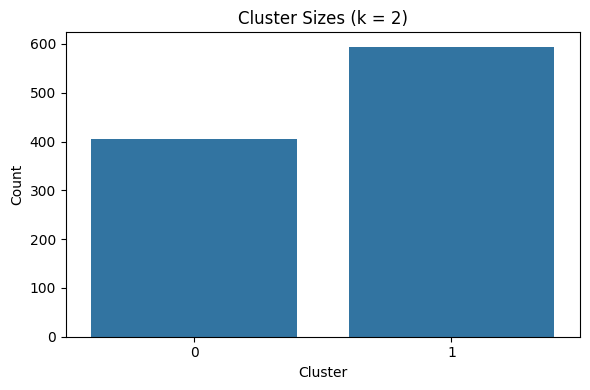

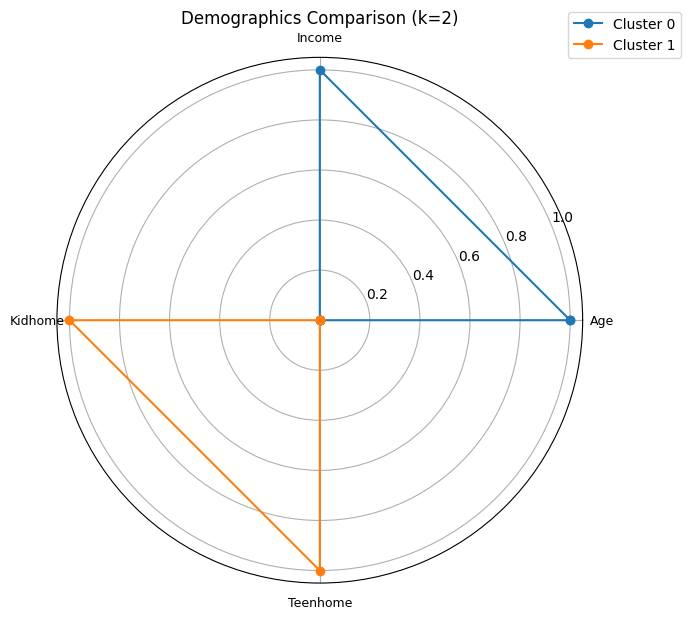

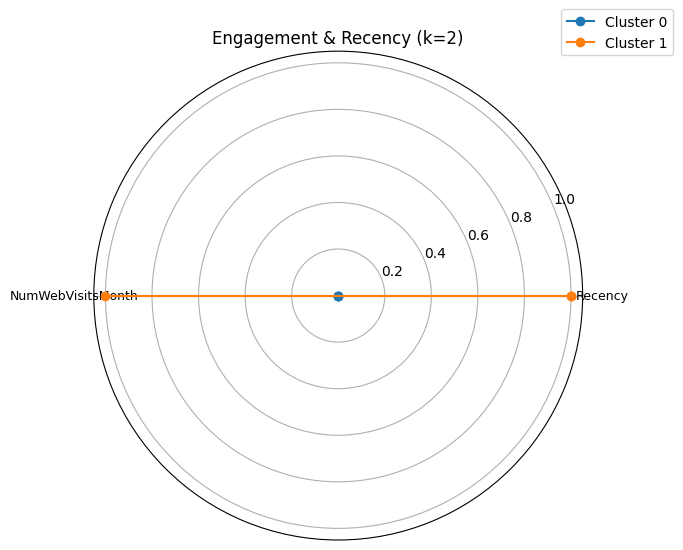

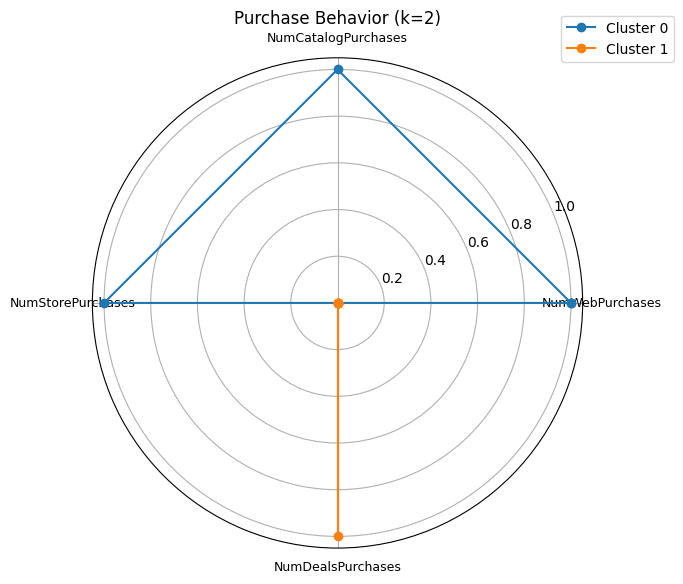

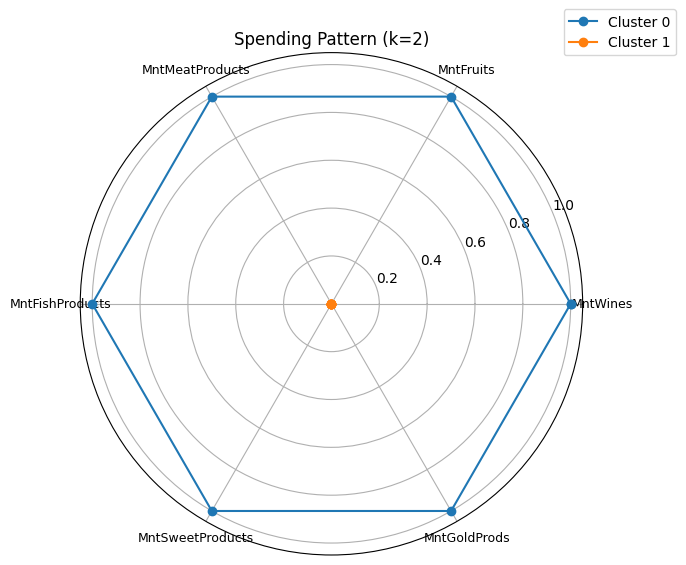

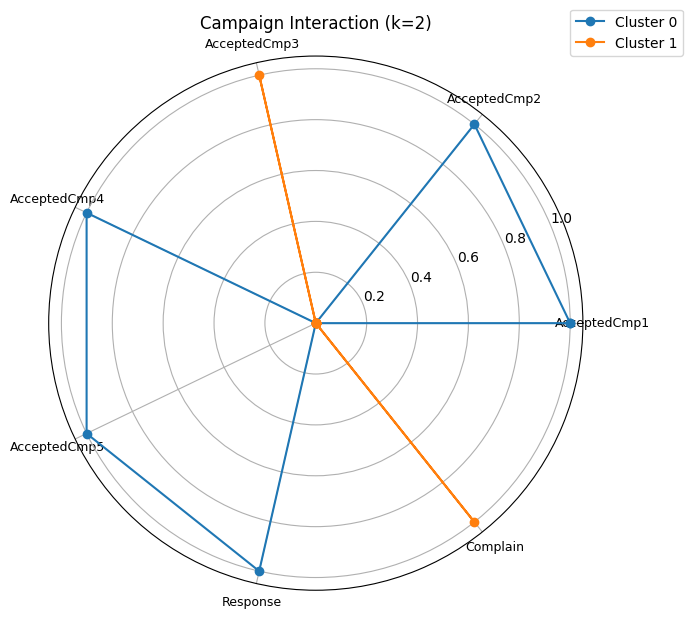

All radar charts generated for k=2!


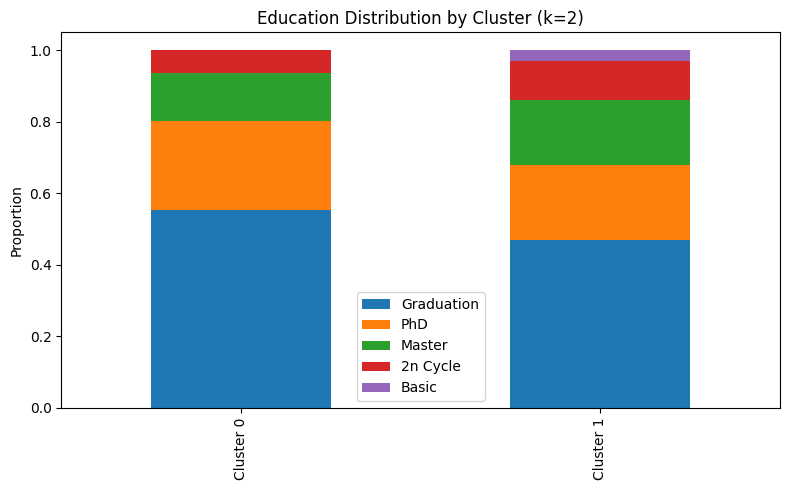

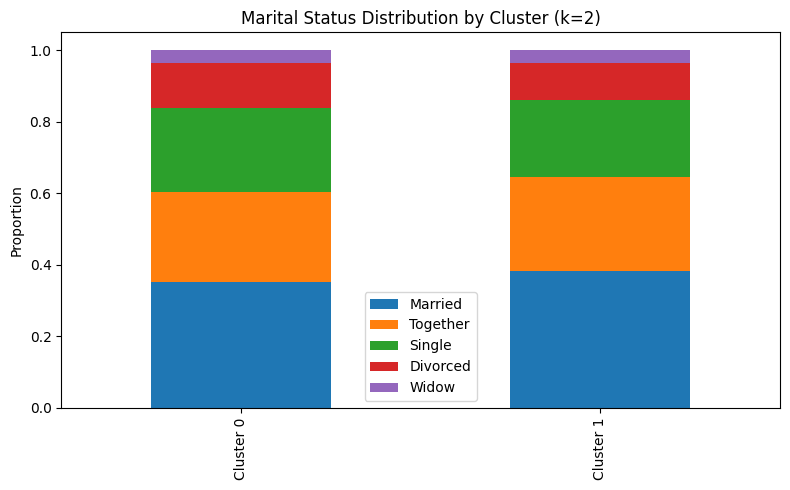


INTERPRETATION OF CLUSTERS (k = 2)

--- Cluster 0 ---
Size: 406 customers (40.60%)

Numeric Feature Means:
 • Age: 57.98
 • Income: 72270.18
 • Recency: 48.02
 • NumWebVisitsMonth: 3.61
 • Kidhome: 0.07
 • Teenhome: 0.40
 • MntWines: 607.01
 • MntFruits: 53.25
 • MntMeatProducts: 368.49
 • MntFishProducts: 78.27
 • MntSweetProducts: 57.07
 • MntGoldProds: 77.31
 • NumDealsPurchases: 2.02
 • NumCatalogPurchases: 5.54
 • NumStorePurchases: 8.51
 • NumWebPurchases: 5.61
 • AcceptedCmp3: 0.07
 • AcceptedCmp4: 0.13
 • AcceptedCmp5: 0.17
 • AcceptedCmp1: 0.16
 • AcceptedCmp2: 0.03
 • Complain: 0.00
 • Response: 0.21

Education Distribution:
 • Graduation: 55.2%
 • PhD: 25.1%
 • Master: 13.3%
 • 2n Cycle: 6.4%

Marital Status Distribution:
 • Married: 35.2%
 • Together: 25.1%
 • Single: 23.4%
 • Divorced: 12.6%
 • Widow: 3.7%

Campaign Response Rates:
 • AcceptedCmp3: 6.7%
 • AcceptedCmp4: 13.3%
 • AcceptedCmp5: 17.5%
 • AcceptedCmp1: 15.5%
 • AcceptedCmp2: 3.2%
 • Complain: 0.0%
 • Response

In [38]:

numeric_features = list(clusters_summary[0]["numeric_means"].keys())
print_heading("ANALYZING CLUSTERS FOR k = 2")
plot_cluster_sizes()
generate_all_radar_charts()
plot_education()
plot_marital()
generate_cluster_insights(numeric_features)

print_heading("ALL ANALYSIS COMPLETE!")
print("Generated:")
print(f" - cluster_{k}_sizes.png")
print(f" - cluster_{k}_radar.png")
print(f" - cluster_{k}_education.png")
print(f" - cluster_{k}_marital.png")